# Ampliphi Booking Curve — Analysis

Focused on the analysis that actually shaped modelling decisions, not a full
EDA dump (per the brief: "we don't care about 200 lines of EDA we won't
read"). Five things, in order: (1) headline results, (2) what a curve looks
like, (3) where the model wins/loses per hotel, (4) what drives it
(feature importance), (5) the honest finding — interval coverage under
seasonal extrapolation.


In [1]:

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src.model import BookingCurveModel
from src.data import load_static_context, load_reservations, CHECKPOINTS

plt.rcParams["figure.figsize"] = (10, 4.5)
DATA_DIR = Path("../data")


## 1. Headline results

From `evaluation/results.json` (our model, official evaluator) and `evaluation/compare_production.py` (vs. Ampliphi's own production curve, hotel_C base room only).

In [2]:

results = json.load(open("../evaluation/results.json"))
print(f"Overall MAE:  {results['overall_mae']:.4f}   (heuristic baseline: 0.3478)")
print(f"Weighted MAE: {results['weighted_mae']:.4f}   (heuristic baseline: 0.3476)")
print(f"Monotonicity violations: {results['monotonicity_violation_rate']:.1%}")
print(f"Bound violations:        {results['bound_violation_rate']:.1%}")
print()
for hotel, r in results["by_property"].items():
    print(f"{hotel}: MAE={r['overall_mae']:.4f}  weighted={r['weighted_mae']:.4f}")


Overall MAE:  0.3008   (heuristic baseline: 0.3478)
Weighted MAE: 0.3061   (heuristic baseline: 0.3476)
Monotonicity violations: 0.0%
Bound violations:        0.0%

hotel_C: MAE=0.2810  weighted=0.2644
hotel_H: MAE=0.3296  weighted=0.3667


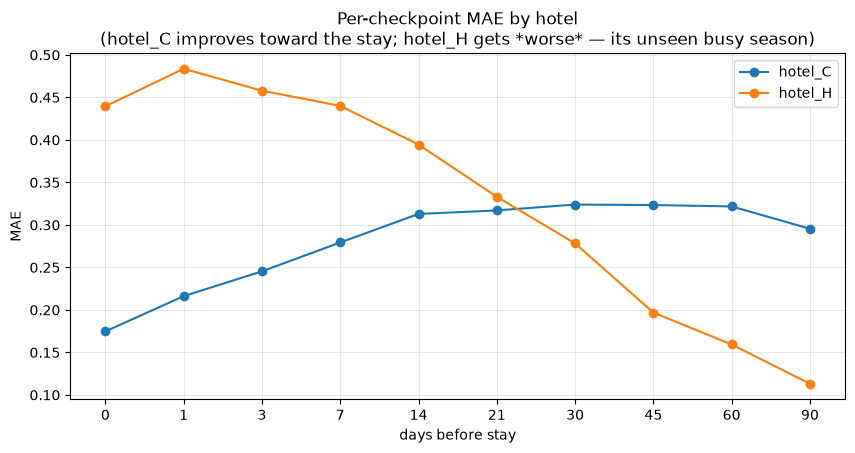

In [3]:

fig, ax = plt.subplots()
cps = CHECKPOINTS
for hotel, r in results["by_property"].items():
    vals = [r["checkpoint_mae"][str(cp)] for cp in cps]
    ax.plot(range(len(cps)), vals, marker="o", label=hotel)
ax.set_xticks(range(len(cps)))
ax.set_xticklabels(cps)
ax.invert_xaxis()
ax.set_xlabel("days before stay")
ax.set_ylabel("MAE")
ax.set_title("Per-checkpoint MAE by hotel\n(hotel_C improves toward the stay; hotel_H gets *worse* — its unseen busy season)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


**Reading this chart is the whole cold-start story in one picture.** `hotel_C` behaves like a normal booking curve model: more information closer to the stay, lower error. `hotel_H` runs backwards — error grows from 0.11 at 90 days out to ~0.40 near the stay, because its Apr-Jun training data never saw its Jul-Sep busy season, so as real late-arriving demand shows up, the gap between our (under-anchored) forecast and reality widens rather than shrinks. See DESIGN.md §6.2.

## 2. What a curve looks like: model vs. actual vs. Ampliphi's production curve

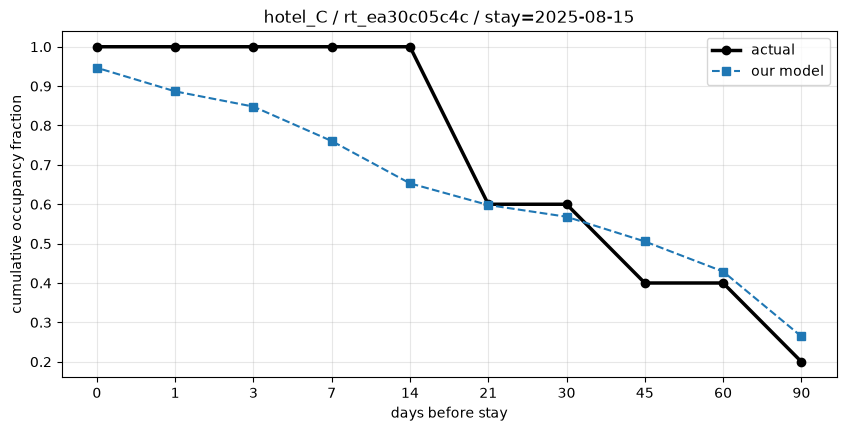

In [4]:

preds = {(p["hotel_id"], p["room_type_code"], p["stay_date"]): p for p in json.load(open("../evaluation/predictions.json"))}
res = load_reservations(DATA_DIR)
ebc = pd.read_csv(DATA_DIR / "expected_booking_curves.csv")
meta = json.load(open(DATA_DIR / "property_metadata.json"))

def actual_curve(hotel, rtc, stay_date_str):
    total = meta[hotel]["room_types"].get(rtc, {}).get("inventory_count", 1)
    sd = pd.Timestamp(stay_date_str)
    sub = res[(res.hotel_id == hotel) & (res.room_type_code == rtc) & (res.stay_date <= sd) & (res.checkout_date > sd)]
    return {cp: min((sub.booking_date <= sd - pd.Timedelta(days=cp)).sum() / total, 1.0) for cp in CHECKPOINTS}

hotel, rtc, stay = "hotel_C", "rt_ea30c05c4c", "2025-08-15"
pred = preds[(hotel, rtc, stay)]["predictions"]
actual = actual_curve(hotel, rtc, stay)

prod_row = ebc[(ebc.hotel_id == hotel) & (ebc.room_type_code == rtc) & (ebc.stay_date == stay)]
total_rooms = meta[hotel]["room_types"][rtc]["inventory_count"]
prod = {int(r.days_until_stay): min(r.expected_occupancy / total_rooms, 1.0) for r in prod_row.itertuples()} if len(prod_row) else None

fig, ax = plt.subplots()
xs = list(range(len(CHECKPOINTS)))
ax.plot(xs, [actual[c] for c in CHECKPOINTS], "o-", label="actual", linewidth=2.5, color="black")
ax.plot(xs, [pred[str(c)] for c in CHECKPOINTS], "s--", label="our model")
if prod:
    ax.plot(xs, [prod.get(c, np.nan) for c in CHECKPOINTS], "^:", label="Ampliphi production curve")
ax.set_xticks(xs); ax.set_xticklabels(CHECKPOINTS); ax.invert_xaxis()
ax.set_xlabel("days before stay"); ax.set_ylabel("cumulative occupancy fraction")
ax.set_title(f"{hotel} / {rtc} / stay={stay}")
ax.legend(); ax.grid(alpha=0.3)
plt.show()


## 3. What drives the model: feature importance

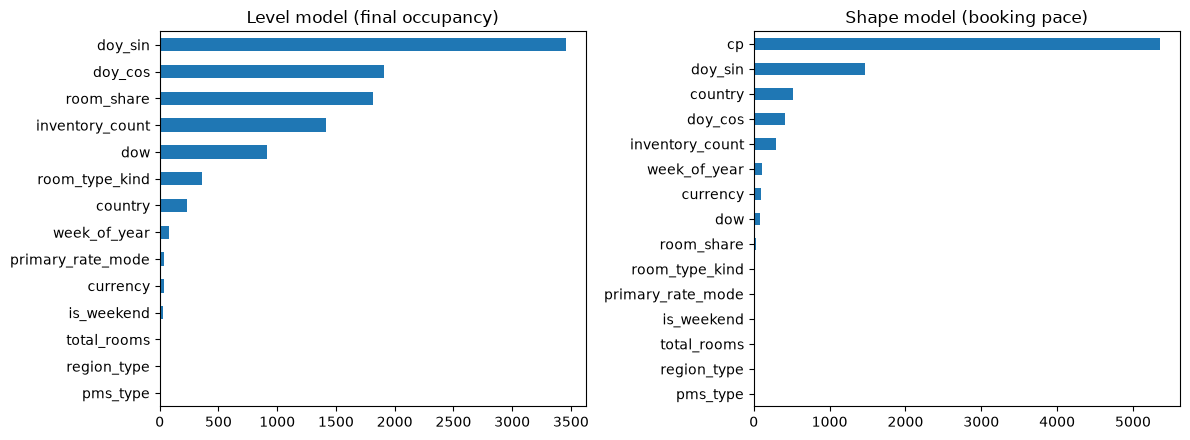

Note: region_type/pms_type/primary_rate_mode/total_rooms get ~0 gain — with only 2
fitted hotels, country/currency are collinear with them. See DESIGN.md 6.1 caveat.


In [5]:

from src.registry import resolve_model_dir
model = BookingCurveModel.load(resolve_model_dir(Path("../artifacts/model")))

def imp_series(booster):
    return pd.Series(
        dict(zip(booster.feature_name(), booster.feature_importance(importance_type="gain")))
    ).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
imp_series(model.level_booster).plot.barh(ax=axes[0], title="Level model (final occupancy)")
imp_series(model.shape_booster).plot.barh(ax=axes[1], title="Shape model (booking pace)")
plt.tight_layout()
plt.show()
print("Note: region_type/pms_type/primary_rate_mode/total_rooms get ~0 gain — with only 2")
print("fitted hotels, country/currency are collinear with them. See DESIGN.md 6.1 caveat.")


## 4. The honest finding: prediction interval coverage under seasonal extrapolation

In [6]:

preds_list = json.load(open("../evaluation/predictions.json"))
extra_inv = {("hotel_C","rt_11ef219078"):13, ("hotel_C","rt_15039fbf2f"):10,
             ("hotel_H","rt_9af5db2336"):1, ("hotel_H","rt_c85cf59a2e"):5}

def actual_curve_full(hotel, rtc, stay_date_str):
    total = extra_inv.get((hotel, rtc), meta[hotel]["room_types"].get(rtc, {}).get("inventory_count", 1))
    sd = pd.Timestamp(stay_date_str)
    sub = res[(res.hotel_id == hotel) & (res.room_type_code == rtc) & (res.stay_date <= sd) & (res.checkout_date > sd)]
    if sub.empty:
        return None
    return {cp: min((sub.booking_date <= sd - pd.Timedelta(days=cp)).sum() / total, 1.0) for cp in CHECKPOINTS}

below = above = total_n = 0
for p in preds_list:
    act = actual_curve_full(p["hotel_id"], p["room_type_code"], p["stay_date"])
    if act is None:
        continue
    for cp in CHECKPOINTS:
        a, lo, hi = act[cp], p["intervals"]["p10"][str(cp)], p["intervals"]["p90"][str(cp)]
        total_n += 1
        below += a < lo
        above += a > hi

picp = (total_n - below - above) / total_n
print(f"Test-window PICP (target 0.80): {picp:.3f}")
print(f"  share below p10: {below/total_n:.3f}   share above p90: {above/total_n:.3f}")
print()
print("54% of actuals land ABOVE p90 -- a one-sided miss. This is the same seasonal-shift")
print("gap as section 3 above, showing up in the interval instead of hidden by a point")
print("estimate. In-distribution (train-window OOF) PICP is 90% -- the calibration")
print("machinery works; it just can't calibrate for a season it has never seen.")
print("Root-caused and discussed in DESIGN.md section 6.7, not tuned away.")


Test-window PICP (target 0.80): 0.380
  share below p10: 0.070   share above p90: 0.551

54% of actuals land ABOVE p90 -- a one-sided miss. This is the same seasonal-shift
gap as section 3 above, showing up in the interval instead of hidden by a point
estimate. In-distribution (train-window OOF) PICP is 90% -- the calibration
machinery works; it just can't calibrate for a season it has never seen.
Root-caused and discussed in DESIGN.md section 6.7, not tuned away.


## 5. Data quality finding: orphaned room types

`reservations.csv` references 4 `room_type_code`s absent from `room_types.csv` — 655 and 536 reservations on two of them for hotel_C alone. `src/data.py::_repair_missing_room_types` patches this; the cell below is the detection logic in isolation.

In [7]:

room_types = pd.read_csv(DATA_DIR / "room_types.csv")
known = set(zip(room_types.hotel_id, room_types.room_type_code))
missing = sorted(set(zip(res.hotel_id, res.room_type_code)) - known)
counts = res.groupby(["hotel_id", "room_type_code"]).size()
for h, rtc in missing:
    print(f"{h}/{rtc}: {counts[(h, rtc)]} reservations, absent from room_types.csv")


hotel_C/rt_11ef219078: 655 reservations, absent from room_types.csv
hotel_C/rt_15039fbf2f: 536 reservations, absent from room_types.csv
hotel_H/rt_9af5db2336: 1 reservations, absent from room_types.csv
hotel_H/rt_c85cf59a2e: 34 reservations, absent from room_types.csv
